# NLP-project-Emotion-Classification
## Team Member: 
- Bhavana Ramesh 

## Preprocessing Pipeline

This notebook prepares raw tweet text for all downstream models:
- Fully Connected Neural Network (TF-IDF)
- LSTM / BiLSTM (sequence-based)
- Transformer-based model (Hugging Face)

Minimal preprocessing is applied to preserve emotional cues
and to avoid any form of data leakage.

The preprocessing pipeline is applied independently to train, validation, and test splits to prevent information leakage.



In [1]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
import re
import os
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
BASE_PATH = "../dataset"

TRAIN_PATH = os.path.join(BASE_PATH, "train.txt")
TEST_PATH = os.path.join(BASE_PATH, "test.txt")
VAL_PATH = os.path.join(BASE_PATH, "validation.txt")

assert os.path.exists(TRAIN_PATH), "train.txt not found"
assert os.path.exists(TEST_PATH), "test.txt not found"
assert os.path.exists(VAL_PATH), "validation.txt not found"

print("Dataset files found.")


Dataset files found.


In [3]:
def load_txt_dataset(path):
    """
    Dataset format:
    sentence ; emotion_label
    """
    return pd.read_csv(
        path,
        sep=";",
        header=None,
        names=["text", "label"],
        engine="python"
    )

train_df = load_txt_dataset(TRAIN_PATH)
test_df = load_txt_dataset(TEST_PATH)
val_df = load_txt_dataset(VAL_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Validation shape:", val_df.shape)

train_df.head()


Train shape: (16000, 2)
Test shape: (2000, 2)
Validation shape: (2000, 2)


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [4]:
print("Train labels:", train_df["label"].unique())
print("Test labels:", test_df["label"].unique())
print("Validation labels:", val_df["label"].unique())


Train labels: <ArrowStringArray>
['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']
Length: 6, dtype: str
Test labels: <ArrowStringArray>
['sadness', 'joy', 'fear', 'anger', 'love', 'surprise']
Length: 6, dtype: str
Validation labels: <ArrowStringArray>
['sadness', 'love', 'anger', 'joy', 'fear', 'surprise']
Length: 6, dtype: str


In [5]:
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove Twitter mentions
    text = re.sub(r"@\w+", "", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Lowercase only
    return text.lower()


In [6]:
for df in [train_df, test_df, val_df]:
    df["clean_text"] = df["text"].apply(clean_text)

train_df.head()


,text,label,clean_text
0,i didnt feel humiliated,sadness,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,anger,i am feeling grouchy


In [7]:
assert train_df.isnull().sum().sum() == 0
assert test_df.isnull().sum().sum() == 0
assert val_df.isnull().sum().sum() == 0

print("No missing values found.")


No missing values found.


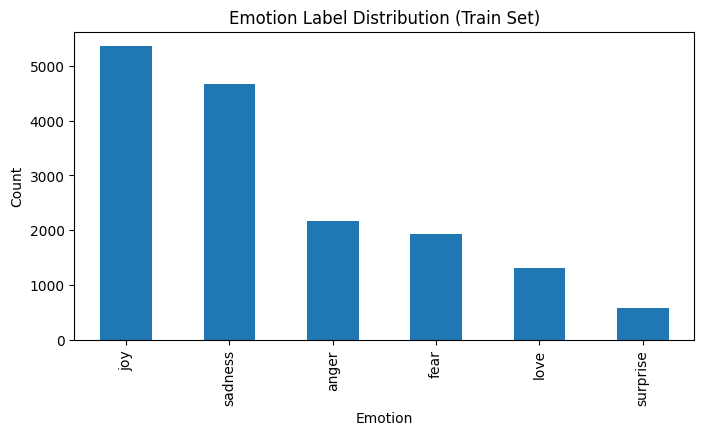

In [8]:
plt.figure(figsize=(8, 4))
train_df["label"].value_counts().plot(kind="bar")
plt.title("Emotion Label Distribution (Train Set)")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()


### Label Distribution

The dataset is not perfectly balanced across emotion categories.
Therefore, F1-score will be reported in addition to accuracy
in all subsequent model evaluations.


In [9]:
train_clean = train_df[["clean_text", "label"]]
test_clean = test_df[["clean_text", "label"]]
val_clean = val_df[["clean_text", "label"]]


In [10]:
train_clean.to_csv(os.path.join(BASE_PATH, "train_clean.csv"), index=False)
test_clean.to_csv(os.path.join(BASE_PATH, "test_clean.csv"), index=False)
val_clean.to_csv(os.path.join(BASE_PATH, "validation_clean.csv"), index=False)

print("Clean CSV files saved successfully.")


Clean CSV files saved successfully.


### Dataset Usage Policy

- Raw `.txt` files are preserved unchanged
- Cleaned `.csv` files are used for modeling
- Labels are never altered
- The validation set is NOT used for training or hyperparameter tuning


In [11]:
assert set(train_df.columns) == {"text", "label", "clean_text"}
assert train_df.isnull().sum().sum() == 0
assert test_df.isnull().sum().sum() == 0
assert val_df.isnull().sum().sum() == 0

print("Notebook 1 verified successfully.")


Notebook 1 verified successfully.


### Preprocessing Output Summary

Generated files:
- `train_clean.csv`
- `test_clean.csv`
- `validation_clean.csv`

These files are used consistently across all subsequent notebooks
to ensure fair and reproducible comparison between models.
